# 02 — Fine-tune `final_preset_final` (epoch 27) on BCIC-IV 2a

Same procedure as notebook 01, but using the larger `final_preset` architecture (12-layer, embed_dim 768). All learned weights transfer directly across channel counts; only the channel/patch dimensions of the encoder config change.

Comparison target — EEG-FM-Bench Table 2 BCIC-2a B-Acc:
EEGPT 44.07 · CsBrain 36.23 · BENDR 35.21 · CBraMod 33.71 · REVE 32.73 · LaBraM 28.50 · BIOT 22.08 (chance 25.0).

## 1. Imports + config

In [1]:
import json, sys, copy
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

REPO_ROOT = Path('..').resolve().parent
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / 'eeg_transfer'))

from src.configs import final_preset
from src.tokenizer import ECGTokenizer
from src.encoder import ECGEncoder
from shared.data import BCICDataset
from shared.train import fit, evaluate, make_warmup_cosine_scheduler, count_params

RUN_NAME = 'final_preset'
CKPT_PATH = REPO_ROOT / 'checkpoints' / 'final_preset_final' / 'checkpoint_epoch_27.pt'
DATA_DIR  = REPO_ROOT / 'eeg_transfer' / 'data' / 'processed'
OUT_DIR   = REPO_ROOT / 'eeg_transfer' / 'results' / RUN_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 0
EPOCHS = 30
WARMUP = 3
BATCH_SIZE = 128
LR_HEAD = 1e-3
LR_BACKBONE = 1e-4   # 1/10 differential LR per EEG-FM-Bench protocol
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0

torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 2. Load processed splits

In [2]:
train_ds = BCICDataset(DATA_DIR / 'train.npz')
val_ds   = BCICDataset(DATA_DIR / 'val.npz')
test_ds  = BCICDataset(DATA_DIR / 'test.npz')
print('train', len(train_ds), 'val', len(val_ds), 'test', len(test_ds))

g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  generator=g, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

train 1337 val 490 test 501


## 3. Build encoder, load checkpoint

Same approach as notebook 01 — only the preset (and therefore the embed dim, depth, head count) changes.

In [3]:
tok_cfg, enc_cfg, _ = final_preset()
enc_cfg.num_leads   = 22       # was 8
enc_cfg.num_patches = 20       # was 50
enc_cfg.use_flash   = False

tokenizer = ECGTokenizer(tok_cfg)
encoder   = ECGEncoder(enc_cfg, tokenizer)

ckpt  = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
state = ckpt['target_encoder']
missing, unexpected = encoder.load_state_dict(state, strict=False)
print(f'pretrained checkpoint loaded from epoch {ckpt["epoch"]}')
print(f'  missing keys   : {missing}')
print(f'  unexpected keys: {unexpected}')

pretrained checkpoint loaded from epoch 26
  missing keys   : []
  unexpected keys: []


## 4. Classifier head

In [4]:
class EEGClassifier(nn.Module):
    def __init__(self, encoder, embed_dim, num_classes=4):
        super().__init__()
        self.encoder = encoder
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):  # x: (bs, 22, 1000)
        patches = self.encoder.tokenizer.patchify(x)            # (bs, 22, 20, 50)
        tokens  = self.encoder(patches, visible_indices=None)   # (bs, 22*20, D)
        feat    = tokens.mean(dim=1)
        return self.head(self.norm(feat))

model = EEGClassifier(encoder, embed_dim=enc_cfg.embed_dim, num_classes=4).to(device)
n_total, n_train = count_params(model)
print(f'params: total={n_total/1e6:.2f}M, trainable={n_train/1e6:.2f}M')

with torch.no_grad():
    xb, yb = next(iter(train_loader))
    out = model(xb.to(device))
    print('forward OK — input', tuple(xb.shape), '→ output', tuple(out.shape))

params: total=85.10M, trainable=85.10M
forward OK — input (128, 22, 1000) → output (128, 4)


## 5. Optimizer + scheduler

In [5]:
head_params     = list(model.head.parameters()) + list(model.norm.parameters())
backbone_params = list(model.encoder.parameters())

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': LR_BACKBONE},
    {'params': head_params,     'lr': LR_HEAD},
], weight_decay=WEIGHT_DECAY)

scheduler = make_warmup_cosine_scheduler(optimizer, warmup_epochs=WARMUP, total_epochs=EPOCHS)
criterion = nn.CrossEntropyLoss()

## 6. Train

In [6]:
history = fit(
    model, train_loader, val_loader,
    optimizer=optimizer, scheduler=scheduler, criterion=criterion,
    device=device, epochs=EPOCHS, grad_clip=GRAD_CLIP, verbose=True,
)

epoch   1 | train_loss 1.4709 | val bacc 25.20 wf1 11.24 kappa  0.28 | lr 4.00e-05
epoch   2 | train_loss 1.4059 | val bacc 25.07 wf1 16.71 kappa  0.10 | lr 7.00e-05
epoch   3 | train_loss 1.4000 | val bacc 27.02 wf1 19.37 kappa  2.87 | lr 1.00e-04
epoch   4 | train_loss 1.4117 | val bacc 25.64 wf1 12.58 kappa  0.86 | lr 9.97e-05
epoch   5 | train_loss 1.3600 | val bacc 28.69 wf1 26.53 kappa  5.04 | lr 9.87e-05
epoch   6 | train_loss 1.2239 | val bacc 27.87 wf1 17.26 kappa  3.69 | lr 9.70e-05
epoch   7 | train_loss 1.0192 | val bacc 30.15 wf1 29.70 kappa  6.83 | lr 9.47e-05
epoch   8 | train_loss 0.8293 | val bacc 31.12 wf1 29.33 kappa  8.14 | lr 9.18e-05
epoch   9 | train_loss 0.5763 | val bacc 27.46 wf1 26.45 kappa  3.23 | lr 8.83e-05
epoch  10 | train_loss 0.2826 | val bacc 27.86 wf1 25.16 kappa  3.77 | lr 8.43e-05
epoch  11 | train_loss 0.1892 | val bacc 29.35 wf1 26.69 kappa  5.93 | lr 7.99e-05
epoch  12 | train_loss 0.1593 | val bacc 31.52 wf1 30.12 kappa  8.66 | lr 7.50e-05
epoc

## 7. Test

In [7]:
model.load_state_dict(history.best_state_dict)
test_metrics = evaluate(model, test_loader, device)
print(f'TEST  bacc {test_metrics["bacc"]*100:.2f}  '
      f'wf1 {test_metrics["wf1"]*100:.2f}  '
      f'kappa {test_metrics["kappa"]*100:.2f}')

TEST  bacc 29.73  wf1 23.88  kappa 6.39


## 8. Save results

wrote /home/aimakeradmin/shady/TS-JEPA/eeg_transfer/results/final_preset/metrics.json
wrote /home/aimakeradmin/shady/TS-JEPA/eeg_transfer/results/final_preset/best_model.pt


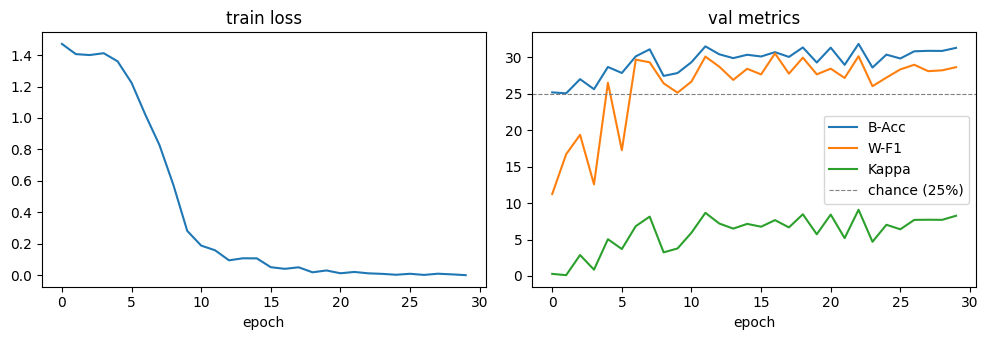

In [8]:
metrics_out = {
    'run_name': RUN_NAME,
    'checkpoint': str(CKPT_PATH.relative_to(REPO_ROOT)),
    'pretrain_epoch': int(ckpt['epoch']),
    'embed_dim': enc_cfg.embed_dim,
    'depth': enc_cfg.depth,
    'n_params_total': n_total,
    'n_params_trainable': n_train,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'lr_head': LR_HEAD,
    'lr_backbone': LR_BACKBONE,
    'weight_decay': WEIGHT_DECAY,
    'best_val_bacc': history.best_val_bacc,
    'best_epoch': history.best_epoch,
    'test_bacc':  test_metrics['bacc'],
    'test_wf1':   test_metrics['wf1'],
    'test_kappa': test_metrics['kappa'],
    'history': {
        'train_loss': history.train_loss,
        'val_bacc':   history.val_bacc,
        'val_wf1':    history.val_wf1,
        'val_kappa':  history.val_kappa,
    },
}
with open(OUT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)
print('wrote', OUT_DIR / 'metrics.json')

torch.save(history.best_state_dict, OUT_DIR / 'best_model.pt')
print('wrote', OUT_DIR / 'best_model.pt')

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(history.train_loss); ax[0].set_title('train loss'); ax[0].set_xlabel('epoch')
ax[1].plot(np.array(history.val_bacc)*100, label='B-Acc')
ax[1].plot(np.array(history.val_wf1)*100,  label='W-F1')
ax[1].plot(np.array(history.val_kappa)*100, label='Kappa')
ax[1].axhline(25.0, color='gray', ls='--', lw=0.8, label='chance (25%)')
ax[1].set_title('val metrics'); ax[1].set_xlabel('epoch'); ax[1].legend()
fig.tight_layout()
fig.savefig(OUT_DIR / 'curves.png', dpi=120)
plt.show()

## 9. Comparison vs EEG-FM-Bench Table 2

In [9]:
baselines = {
    'EEGPT (best)': 44.07, 'CsBrain': 36.23, 'BENDR': 35.21,
    'CBraMod': 33.71, 'REVE': 32.73, 'LaBraM': 28.50, 'BIOT': 22.08,
}
ours = test_metrics['bacc'] * 100
print(f'{"Model":<22} {"B-Acc":>7}  Δ vs EEGPT')
print('-' * 42)
for name, score in baselines.items():
    print(f'{name:<22} {score:>6.2f}   {score - 44.07:+6.2f}')
print(f'{"OURS (" + RUN_NAME + ")":<22} {ours:>6.2f}   {ours - 44.07:+6.2f}')

Model                    B-Acc  Δ vs EEGPT
------------------------------------------
EEGPT (best)            44.07    +0.00
CsBrain                 36.23    -7.84
BENDR                   35.21    -8.86
CBraMod                 33.71   -10.36
REVE                    32.73   -11.34
LaBraM                  28.50   -15.57
BIOT                    22.08   -21.99
OURS (final_preset)     29.73   -14.34
